# Mutual Fund Analytics - Exploratory Data Analysis

## Objective

Analyze mutual fund industry data and identify trends in:

- NAV Growth
- AUM Growth
- SIP Inflows
- Category Inflows
- Investor Demographics
- Geographic Distribution
- Folio Growth
- NAV Correlations
- Portfolio Sector Allocation

Period: 2022-2025

In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Environment Ready!")

Environment Ready!


# 1. NAV Trend Analysis

### Objective
Analyze the NAV movement of selected mutual fund schemes from 2022–2025.

In [40]:
import pandas as pd

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [41]:
print(nav_df.shape)
print(nav_df.columns)

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [42]:
import pandas as pd
import plotly.express as px

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

# Select first 5 schemes for visualization
selected_funds = nav_df["amfi_code"].unique()[:5]

filtered_df = nav_df[nav_df["amfi_code"].isin(selected_funds)]

fig = px.line(
    filtered_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (Selected Funds)"
)

fig.show()

### Insight

- NAV values show an overall upward trend from 2022 to 2025.
- Most schemes recovered strongly after market corrections.
- Daily fluctuations are visible, but long-term performance remains positive.
- Selected schemes exhibit similar growth patterns over the analysis period.

# 2. AUM Growth Analysis

### Objective
Analyze Assets Under Management (AUM) growth across major mutual fund houses from 2022–2025.

In [43]:
import pandas as pd

aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [44]:
print(aum_df.shape)
print(aum_df.columns)

(90, 5)
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


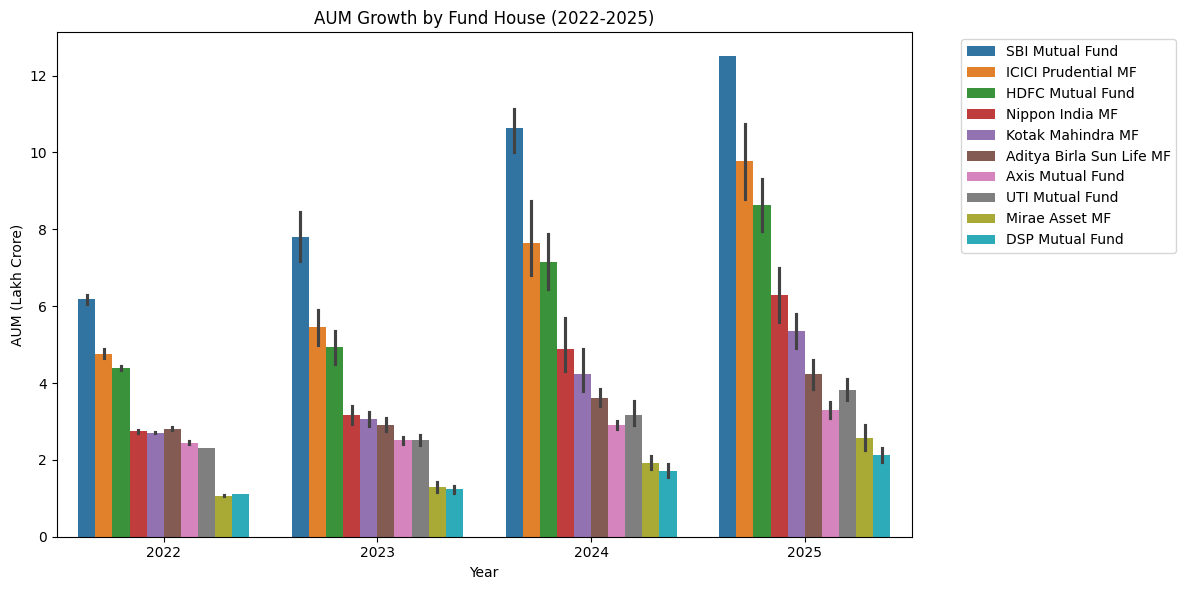

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

### Insight

- SBI Mutual Fund consistently maintained the highest AUM during the analysis period.
- ICICI Prudential and HDFC Mutual Fund remained among the top asset managers.
- Most fund houses showed steady AUM growth between 2022 and 2025.
- Growth indicates increasing investor participation in mutual funds.

# 3. SIP Trend Analysis

### Objective
Analyze monthly SIP inflows from 2022 to 2025 and identify long-term growth trends.

In [46]:
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [47]:
print(sip_df.shape)
print(sip_df.columns)

(48, 6)
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [48]:
import pandas as pd
import plotly.express as px

sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip_df["month"] = pd.to_datetime(sip_df["month"])

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

# All-time high point
max_row = sip_df.loc[sip_df["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"All Time High ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

### Insight

- SIP inflows increased consistently from 2022 to 2025.
- Monthly inflows grew from around ₹11,500 Cr in early 2022 to over ₹31,000 Cr by the end of 2025.
- The all-time high SIP inflow was recorded in December 2025.
- Rising SIP contributions indicate growing retail investor confidence and long-term participation in mutual funds.

# 4. Category Inflow Heatmap

### Objective
Analyze category-wise inflows and identify which fund categories attracted the highest investments.

In [49]:
category_df = pd.read_csv("../data/raw/05_category_inflows.csv")

category_df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [50]:
print(category_df.shape)
print(category_df.columns)

(144, 3)
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


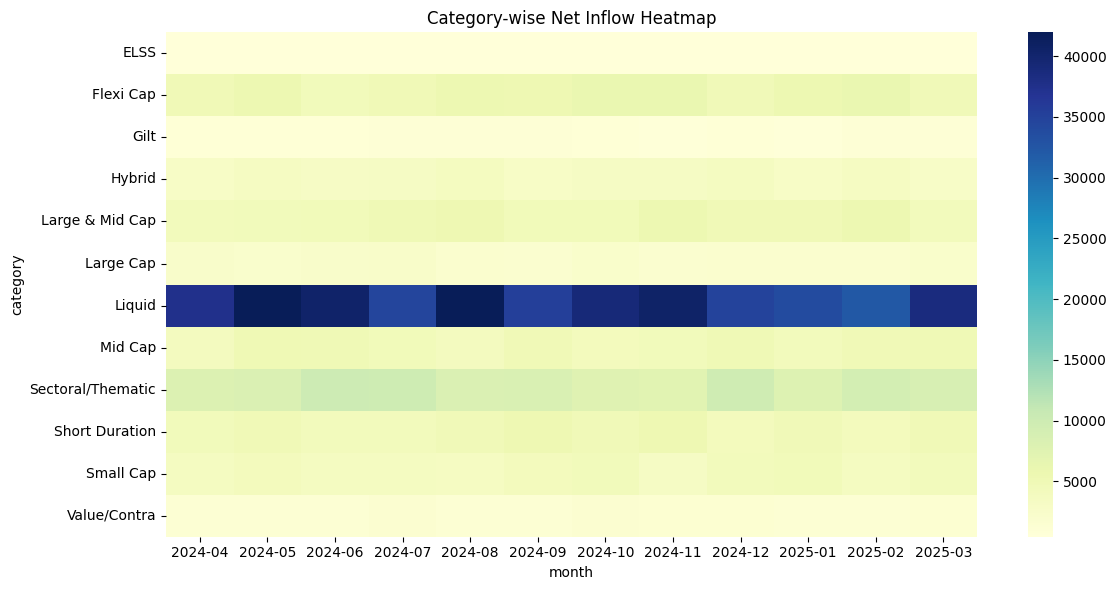

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_df, cmap="YlGnBu")

plt.title("Category-wise Net Inflow Heatmap")
plt.tight_layout()
plt.show()

### Insight

- Flexi Cap, Mid Cap and Large & Mid Cap categories attracted strong inflows.
- Equity-oriented categories consistently received higher investments than most other categories.
- Investor preference remained focused on growth-oriented funds.
- Higher inflows indicate strong participation in diversified and equity-based investment products.

# 5. Investor Demographics Analysis

### Objective

Analyze investor participation based on age groups and gender distribution.

In [52]:
demo_df = pd.read_csv("../data/raw/08_investor_transactions.csv")

demo_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


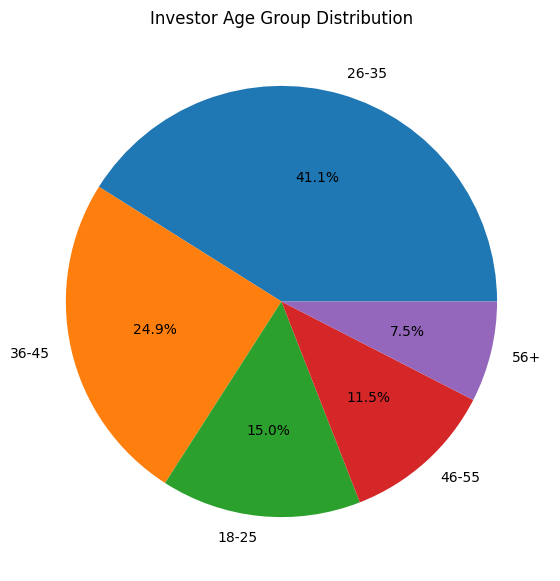

In [53]:
import matplotlib.pyplot as plt

age_counts = demo_df["age_group"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.show()

### Insight

- The 26–35 and 36–45 age groups form the largest share of investors.
- Younger investors show strong participation in mutual fund investments.
- Senior investors contribute a smaller proportion compared to working-age groups.
- The investor base is primarily concentrated in the middle-age population.

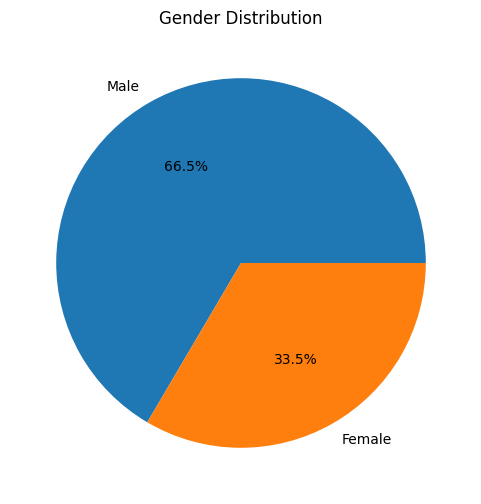

In [54]:
gender_counts = demo_df["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

### Insight

- Male investors account for a larger share of total investors.
- Female participation is significant but lower than male participation.
- The mutual fund industry still shows a gender participation gap.
- Increasing financial awareness may further improve female investor participation.

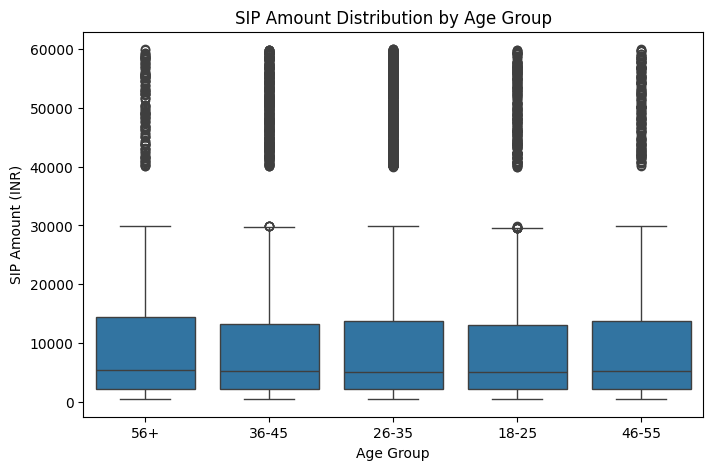

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sip_df = demo_df[demo_df["transaction_type"] == "SIP"]

plt.figure(figsize=(8,5))
sns.boxplot(
    data=sip_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")
plt.show()

### Insight

- The 26–35 and 36–45 age groups contribute the highest SIP amounts.
- Working-age investors show stronger investment participation than other groups.
- SIP investments vary significantly across age categories.
- Younger and middle-aged investors are the primary drivers of systematic investments.

# 6. Geographic Distribution Analysis

### Objective

Analyze investor distribution across states and city tiers.

In [56]:
geo_df = pd.read_csv("../data/raw/08_investor_transactions.csv")

geo_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


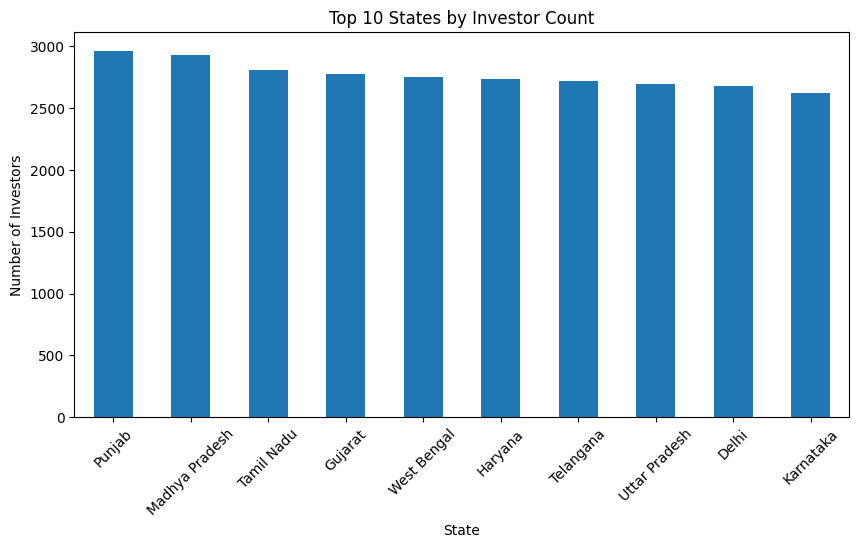

In [57]:
state_counts = geo_df["state"].value_counts().head(10)

plt.figure(figsize=(10,5))
state_counts.plot(kind="bar")

plt.title("Top 10 States by Investor Count")
plt.xlabel("State")
plt.ylabel("Number of Investors")
plt.xticks(rotation=45)

plt.show()

### Insight

- Punjab and Madhya Pradesh have the highest investor participation.
- Investor distribution is spread across multiple states rather than concentrated in one region.
- Northern and western states contribute significantly to mutual fund investments.
- The broad state-level participation reflects growing mutual fund penetration across India.

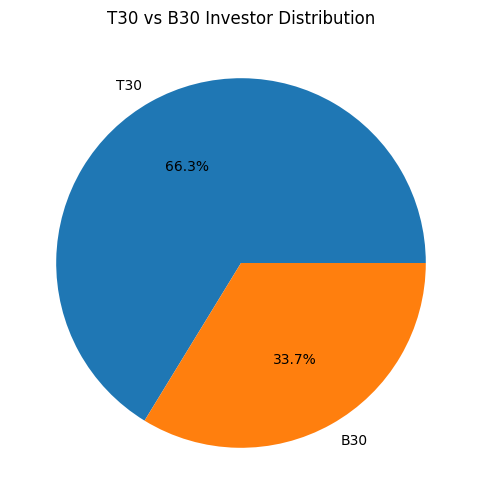

In [58]:
tier_counts = geo_df["city_tier"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")
plt.show()

### Insight

- T30 cities account for the majority of investors.
- B30 cities still contribute a meaningful share of total participation.
- Mutual fund adoption remains stronger in metropolitan areas.
- Growing B30 participation indicates expanding financial awareness beyond major cities.

# 7. Folio Growth Analysis

### Objective

Analyze the growth in mutual fund folio counts from 2022–2025.

In [59]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [60]:
print(folio_df.shape)
print(folio_df.columns)

(21, 6)
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [61]:
fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    title="Mutual Fund Folio Growth (2022-2025)"
)

fig.show()

### Insight

- Mutual fund folio count increased from around 13 Cr in 2022 to over 26 Cr by 2025.
- The number of investor accounts nearly doubled during the period.
- Growth accelerated during 2024–2025, indicating strong retail participation.
- Rising folio counts reflect increasing adoption of mutual funds as an investment vehicle.

# 8. NAV Return Correlation Analysis

### Objective

Analyze the correlation between returns of selected mutual fund schemes.

In [62]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [63]:
print(nav_df.shape)
print(nav_df.columns)

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')


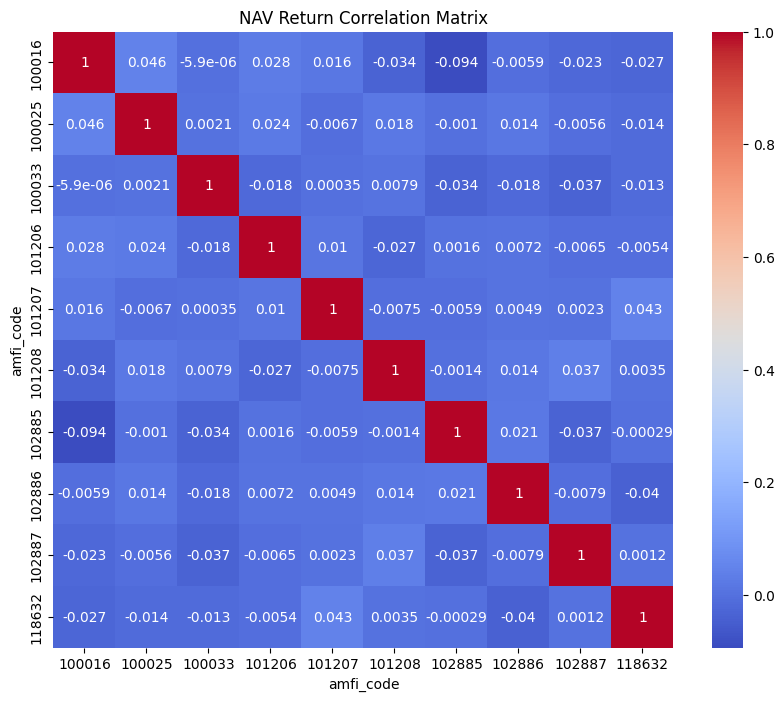

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date column
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Select 10 funds
selected_funds = nav_df["amfi_code"].unique()[:10]

filtered_df = nav_df[nav_df["amfi_code"].isin(selected_funds)]

# Create pivot table
pivot_df = filtered_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns_df = pivot_df.pct_change().dropna()

# Correlation matrix
corr_matrix = returns_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

### Insight

- Most fund pairs show weak correlations.
- Diversification benefits remain available across different schemes.
- No pair of funds exhibits extremely strong positive correlation.
- Investors can reduce risk by holding multiple funds with low correlation.

# 9. Sector Allocation Analysis

### Objective

Analyze sector-wise allocation across equity mutual fund portfolios.

In [65]:
portfolio_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [66]:
sector_weights = (
    portfolio_df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

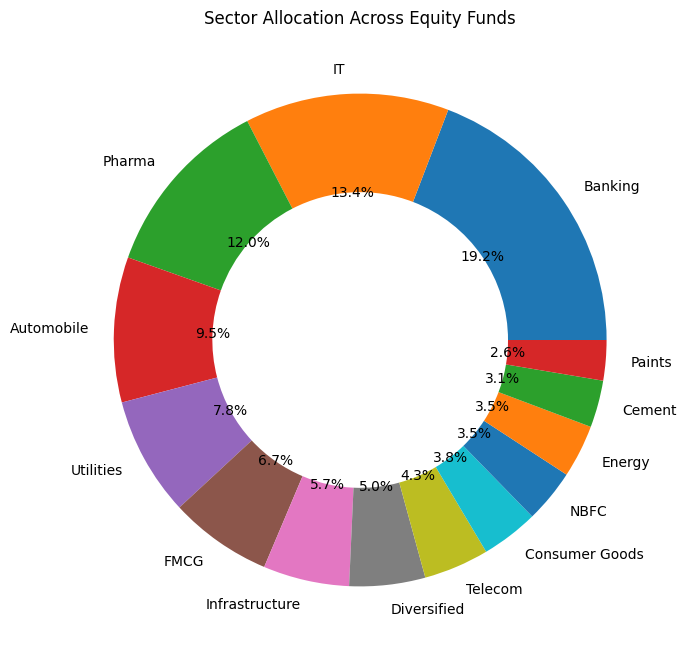

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Insight

- Banking is the largest sector allocation across equity mutual funds.
- IT and Pharma also receive significant portfolio weights.
- Fund managers maintain diversification across multiple sectors.
- Sector allocation reflects a preference for financially strong and growth-oriented industries.